<a href="https://colab.research.google.com/github/krithi-ks/PetroVision/blob/main/notebooks/computer-vision/PetroVision_U-Net_No_Augmentation_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV-UNET-005 — No Data Augmentation Experiment

**Experiment ID:** CV-UNET-005

This experiment evaluates the effect of training-time data augmentation
on petroleum-contamination segmentation.

The model architecture, dataset split, loss function, optimizer,
learning rate, image size, batch size, number of epochs, and evaluation
procedure are kept consistent with CV-UNET-003.

The only experimental change is disabling training augmentation.

## Imports

In [1]:
import sys
import json
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

PyTorch version: 2.11.0+cu128
Device: cuda


## Project setup

In [3]:
!git clone https://github.com/krithi-ks/PetroVision.git
%cd PetroVision

from pathlib import Path

print("Project root:", Path.cwd())
print("\nProject files:")
for item in sorted(Path(".").iterdir()):
    print(" -", item.name)

Cloning into 'PetroVision'...
remote: Enumerating objects: 234, done.
remote: Total 234 (delta 0), reused 0 (delta 0), pack-reused 234 (from 1)
Receiving objects: 100% (234/234), 71.49 MiB | 31.84 MiB/s, done.
Resolving deltas: 100% (77/77), done.
/content/PetroVision
Project root: /content/PetroVision

Project files:
 - .git
 - .gitignore
 - README.md
 - app
 - data
 - docs
 - models
 - notebooks
 - references
 - reports
 - requirements.txt
 - results
 - src


In [2]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/PetroVision")
DRIVE_ROOT = Path("/content/drive/MyDrive/PetroVision")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Drive root:", DRIVE_ROOT)

Mounted at /content/drive
Project root: /content/PetroVision
Drive root: /content/drive/MyDrive/PetroVision


In [4]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/PetroVision/datasets/"
    "PetroVision.v1i.png-mask-semantic.zip"
)

EXTRACT_DIR = Path("/content/PetroVision/data/lados")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:", EXTRACT_DIR)

Dataset extracted to: /content/PetroVision/data/lados


## Dataset

In [5]:
from torch.utils.data import DataLoader
from src.vision.lados_dataset import LADOSDataset

DATASET_ROOT = PROJECT_ROOT / "data" / "lados"

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16

train_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="train",
    image_size=IMAGE_SIZE,
    augment=False
)

valid_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="valid",
    image_size=IMAGE_SIZE,
    augment=False
)

test_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="test",
    image_size=IMAGE_SIZE,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Train:", len(train_dataset))
print("Validation:", len(valid_dataset))
print("Test:", len(test_dataset))

Train: 2370
Validation: 675
Test: 343


## Model and loss

In [6]:
from src.vision.unet import UNet

model = UNet(
    in_channels=3,
    out_channels=1
).to(DEVICE)

criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

EPOCHS = 20

print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

Trainable parameters: 1942577


## Training

In [7]:
history = {
    "train_loss": [],
    "validation_loss": []
}

best_validation_loss = float("inf")
best_epoch = None

OUTPUT_DIR = DRIVE_ROOT / "results" / "cv_unet_005"
MODEL_DIR = DRIVE_ROOT / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = MODEL_DIR / "cv_unet_005_best.pt"

for epoch in range(EPOCHS):

    model.train()
    train_loss_total = 0.0

    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        train_loss_total += loss.item()

    train_loss = train_loss_total / len(train_loader)

    model.eval()
    validation_loss_total = 0.0

    with torch.no_grad():
        for images, masks in valid_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(images)
            loss = criterion(logits, masks)

            validation_loss_total += loss.item()

    validation_loss = validation_loss_total / len(valid_loader)

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "experiment_id": "CV-UNET-005",
                "model_state_dict": model.state_dict(),
                "best_epoch": best_epoch,
                "best_validation_loss": best_validation_loss
            },
            CHECKPOINT_PATH
        )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {validation_loss:.6f}"
    )

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_validation_loss)
print("Checkpoint:", CHECKPOINT_PATH)

Epoch 01/20 | Train Loss: 0.616578 | Validation Loss: 0.617835
Epoch 02/20 | Train Loss: 0.587883 | Validation Loss: 0.583780
Epoch 03/20 | Train Loss: 0.584034 | Validation Loss: 0.564676
Epoch 04/20 | Train Loss: 0.571789 | Validation Loss: 0.568529
Epoch 05/20 | Train Loss: 0.573789 | Validation Loss: 0.564304
Epoch 06/20 | Train Loss: 0.560660 | Validation Loss: 0.566763
Epoch 07/20 | Train Loss: 0.545265 | Validation Loss: 0.537700
Epoch 08/20 | Train Loss: 0.532497 | Validation Loss: 0.536339
Epoch 09/20 | Train Loss: 0.521795 | Validation Loss: 0.519065
Epoch 10/20 | Train Loss: 0.514675 | Validation Loss: 0.510937
Epoch 11/20 | Train Loss: 0.504289 | Validation Loss: 0.517312
Epoch 12/20 | Train Loss: 0.495382 | Validation Loss: 0.554607
Epoch 13/20 | Train Loss: 0.491383 | Validation Loss: 0.500078
Epoch 14/20 | Train Loss: 0.482033 | Validation Loss: 0.509421
Epoch 15/20 | Train Loss: 0.481357 | Validation Loss: 0.542243
Epoch 16/20 | Train Loss: 0.482859 | Validation Loss: 0

## Save history

In [8]:
HISTORY_PATH = OUTPUT_DIR / "training_history.json"

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=2)

print("History:", HISTORY_PATH)

History: /content/drive/MyDrive/PetroVision/results/cv_unet_005/training_history.json


## Training curves

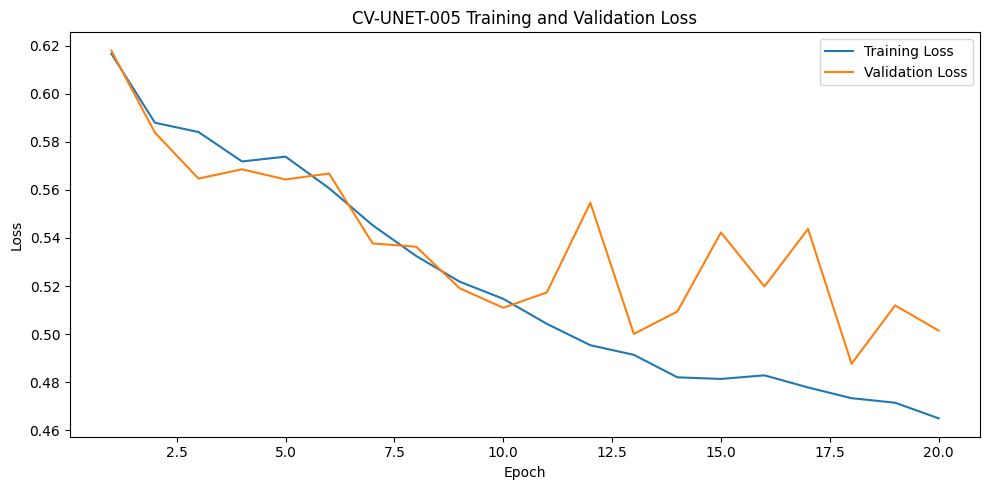

In [9]:
plt.figure(figsize=(10, 5))

epochs = range(1, len(history["train_loss"]) + 1)

plt.plot(
    epochs,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CV-UNET-005 Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Load best checkpoint

In [10]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Loaded best checkpoint from epoch:", checkpoint["best_epoch"])

Loaded best checkpoint from epoch: 18


## Test evaluation

In [11]:
tp = fp = fn = tn = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE)

        logits = model(images)
        probabilities = torch.sigmoid(logits)

        predictions = (probabilities >= 0.5).float()
        targets = (masks >= 0.5).float().to(DEVICE)

        tp += ((predictions == 1) & (targets == 1)).sum().item()
        fp += ((predictions == 1) & (targets == 0)).sum().item()
        fn += ((predictions == 0) & (targets == 1)).sum().item()
        tn += ((predictions == 0) & (targets == 0)).sum().item()

iou = tp / (tp + fp + fn) if (tp + fp + fn) else 0
dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
accuracy = (tp + tn) / (tp + fp + fn + tn)

test_metrics = {
    "experiment_id": "CV-UNET-005",
    "best_epoch": checkpoint["best_epoch"],
    "validation_loss": checkpoint["best_validation_loss"],
    "IoU": iou,
    "Dice": dice,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "TP": tp,
    "FP": fp,
    "FN": fn,
    "TN": tn
}

print(json.dumps(test_metrics, indent=2))

{
  "experiment_id": "CV-UNET-005",
  "best_epoch": 18,
  "validation_loss": 0.4876784765443137,
  "IoU": 0.6315037331243126,
  "Dice": 0.7741370372656022,
  "Precision": 0.8193564797720833,
  "Recall": 0.7336477703929926,
  "Accuracy": 0.7720576250170827,
  "TP": 8780959,
  "FP": 1935938,
  "FN": 3187944,
  "TN": 8574007
}


## Save metrics

In [12]:
METRICS_PATH = OUTPUT_DIR / "test_metrics.json"

with open(METRICS_PATH, "w") as f:
    json.dump(test_metrics, f, indent=2)

print("Metrics:", METRICS_PATH)

Metrics: /content/drive/MyDrive/PetroVision/results/cv_unet_005/test_metrics.json


## Metric visualization

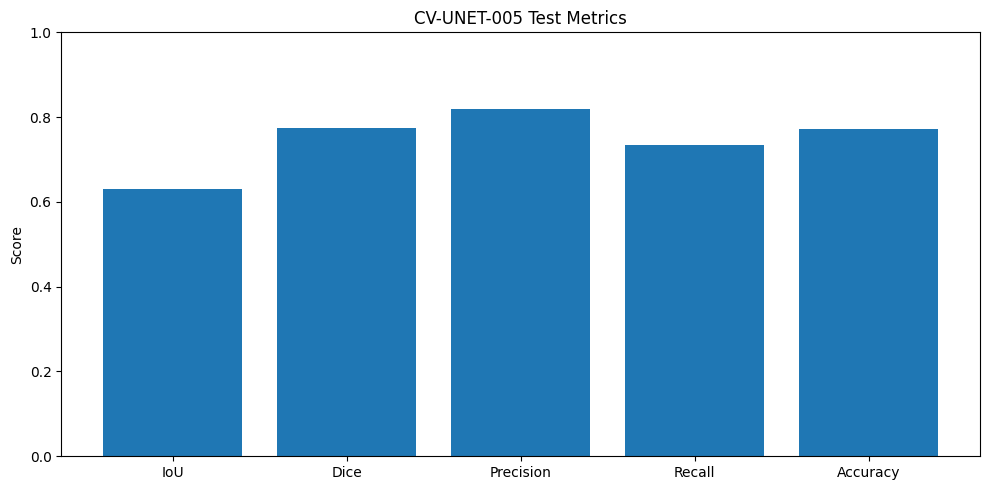

In [13]:
metric_names = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

metric_values = [
    test_metrics[name]
    for name in metric_names
]

plt.figure(figsize=(10, 5))

plt.bar(
    metric_names,
    metric_values
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("CV-UNET-005 Test Metrics")
plt.tight_layout()
plt.show()

## Qualitative predictions

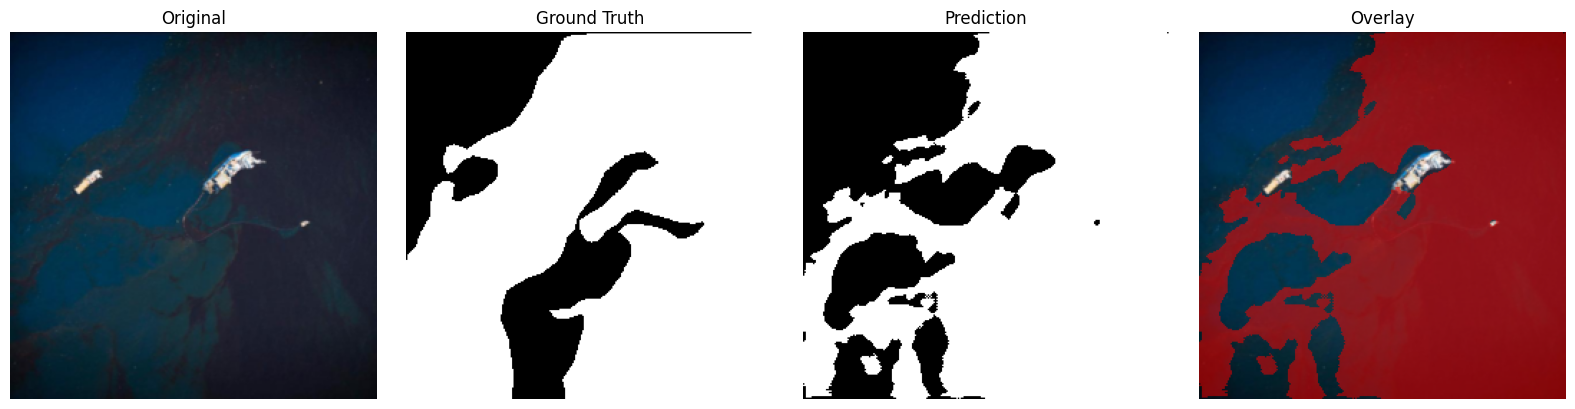

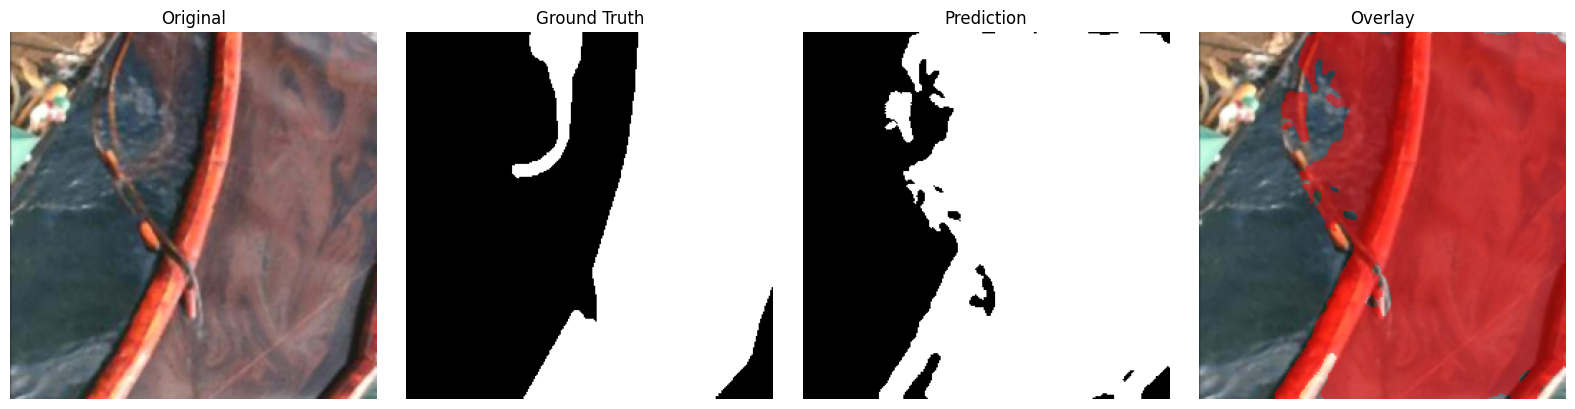

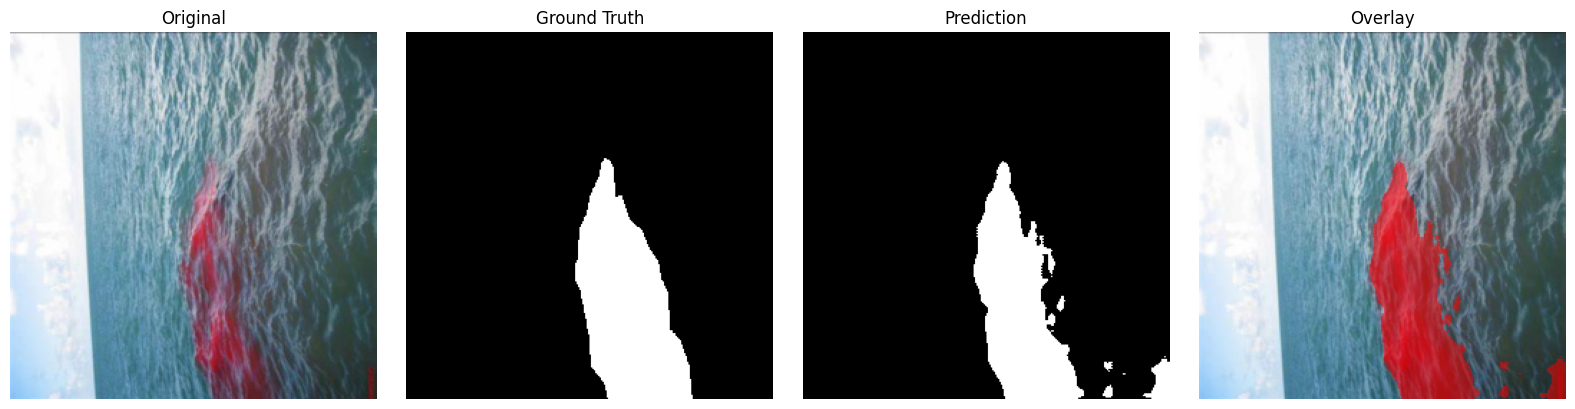

In [14]:
sample_indices = [0, 100, 200]

for index in sample_indices:

    image, mask = test_dataset[index]

    with torch.no_grad():
        logits = model(
            image.unsqueeze(0).to(DEVICE)
        )

        prediction = (
            torch.sigmoid(logits)[0, 0]
            >= 0.5
        ).cpu().numpy()

    image_np = image.permute(1, 2, 0).numpy()
    mask_np = mask.squeeze().numpy()

    overlay = image_np.copy()
    overlay[prediction == 1] = (
        0.5 * overlay[prediction == 1] +
        0.5 * np.array([1, 0, 0])
    )

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(image_np)
    axes[0].set_title("Original")

    axes[1].imshow(mask_np, cmap="gray")
    axes[1].set_title("Ground Truth")

    axes[2].imshow(prediction, cmap="gray")
    axes[2].set_title("Prediction")

    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Experiment Summary

### What was tested

CV-UNET-005 evaluates the effect of disabling training-time data
augmentation on petroleum-contamination segmentation.

### Why this experiment was needed

Data augmentation can expose a model to variations of the training
images and may improve generalization to unseen images. However, its
effect should be experimentally verified rather than assumed.

### Experimental design

CV-UNET-005 uses the same model architecture, dataset split, image
resolution, loss function, optimizer, learning rate, batch size,
number of epochs, and evaluation threshold as CV-UNET-003.

The only intended change is disabling training augmentation.

Validation and test images are not augmented.

### Comparison

CV-UNET-005 will be compared with CV-UNET-003 to determine whether
training augmentation affected the observed segmentation performance.

### Limitation

The result applies to the evaluated LADOS dataset, U-Net configuration,
augmentation pipeline, and training setup. It does not establish that
augmentation will have the same effect on other datasets or models.

## Automatic comparison with CV-UNET-003

In [20]:
BASELINE_PATH = (
    DRIVE_ROOT
    / "results"
    / "cv_unet_003"
    / "test_metrics.json"
)

with open(BASELINE_PATH, "r") as f:
    baseline_metrics = json.load(f)

comparison = pd.DataFrame({
    "Metric": metric_names,
    "CV-UNET-003 (Augmentation)": [
        baseline_metrics[m] for m in metric_names
    ],
    "CV-UNET-005 (No Augmentation)": [
        test_metrics[m] for m in metric_names
    ]
})

comparison["Difference (005 - 003)"] = (
    comparison["CV-UNET-005 (No Augmentation)"]
    - comparison["CV-UNET-003 (Augmentation)"]
)

display(
    comparison.style.format({
        "CV-UNET-003 (Augmentation)": "{:.6f}",
        "CV-UNET-005 (No Augmentation)": "{:.6f}",
        "Difference (005 - 003)": "{:+.6f}"
    })
)

,Metric,CV-UNET-003 (Augmentation),CV-UNET-005 (No Augmentation),Difference (005 - 003)
0,IoU,0.651780,0.631504,-0.020276
1,Dice,0.789185,0.774137,-0.015048
2,Precision,0.804084,0.819356,+0.015273
3,Recall,0.774828,0.733648,-0.041180
4,Accuracy,0.779586,0.772058,-0.007529


## Automatic conclusion

In [16]:
print("=" * 70)
print("CV-UNET-005 — AUTOMATIC EXPERIMENT CONCLUSION")
print("=" * 70)

for metric in metric_names:

    baseline_value = baseline_metrics[metric]
    experiment_value = test_metrics[metric]
    difference = experiment_value - baseline_value

    direction = (
        "increased"
        if difference > 0
        else "decreased"
        if difference < 0
        else "remained unchanged"
    )

    print(
        f"{metric}: {direction} "
        f"by {abs(difference):.6f}"
    )

print("\nExperiment:")
print("Training augmentation disabled.")

print("\nReference:")
print("CV-UNET-003 with training augmentation enabled.")

print("\nInterpretation:")
print(
    "The comparison shows the observed effect of training augmentation "
    "under the controlled experimental setup."
)

print("\nScientific limitation:")
print(
    "The result is specific to the evaluated dataset, architecture, "
    "augmentation pipeline, and training configuration."
)

CV-UNET-005 — AUTOMATIC EXPERIMENT CONCLUSION
IoU: decreased by 0.020276
Dice: decreased by 0.015048
Precision: increased by 0.015273
Recall: decreased by 0.041180
Accuracy: decreased by 0.007529

Experiment:
Training augmentation disabled.

Reference:
CV-UNET-003 with training augmentation enabled.

Interpretation:
The comparison shows the observed effect of training augmentation under the controlled experimental setup.

Scientific limitation:
The result is specific to the evaluated dataset, architecture, augmentation pipeline, and training configuration.


## Save comparison

In [17]:
COMPARISON_PATH = OUTPUT_DIR / "augmentation_comparison.json"

comparison_record = {
    "experiment_id": "CV-UNET-005",
    "baseline_experiment": "CV-UNET-003",
    "baseline_augmentation": True,
    "experiment_augmentation": False,
    "metrics": {
        metric: {
            "baseline": float(baseline_metrics[metric]),
            "experiment": float(test_metrics[metric]),
            "difference": float(
                test_metrics[metric] - baseline_metrics[metric]
            )
        }
        for metric in metric_names
    }
}

with open(COMPARISON_PATH, "w") as f:
    json.dump(comparison_record, f, indent=2)

print("Saved:", COMPARISON_PATH)

Saved: /content/drive/MyDrive/PetroVision/results/cv_unet_005/augmentation_comparison.json


## Verify

In [18]:
required_files = [
    CHECKPOINT_PATH,
    HISTORY_PATH,
    METRICS_PATH,
    COMPARISON_PATH
]

for path in required_files:
    print(
        f"{path}:",
        "FOUND" if path.exists() else "MISSING"
    )

/content/drive/MyDrive/PetroVision/models/cv_unet_005_best.pt: FOUND
/content/drive/MyDrive/PetroVision/results/cv_unet_005/training_history.json: FOUND
/content/drive/MyDrive/PetroVision/results/cv_unet_005/test_metrics.json: FOUND
/content/drive/MyDrive/PetroVision/results/cv_unet_005/augmentation_comparison.json: FOUND
